
# Flight delays Project


## Importing the libraries

In [1]:
pip install xgboost catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 5.4 MB/s eta 0:00:00


In [2]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (f1_score,accuracy_score,precision_score,roc_auc_score,
                                classification_report,roc_curve,recall_score,make_scorer)
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint,ReduceLROnPlateau
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
import pickle



## Uploading the data with help of the pandas library

In [3]:

df = pd.read_csv("/content/flight_delays_train.csv")



## Show the top 5 rows

In [4]:

df.head()

,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min
0,c-8,c-21,c-7,1934,AA,ATL,DFW,732,N
1,c-4,c-20,c-3,1548,US,PIT,MCO,834,N
2,c-9,c-2,c-5,1422,XE,RDU,CLE,416,N
3,c-11,c-25,c-6,1015,OO,DEN,MEM,872,N
4,c-10,c-7,c-6,1828,WN,MDW,OMA,423,Y



## Checking the Null value

In [5]:

df.isnull().sum()

,0
Month,0
DayofMonth,0
DayOfWeek,0
DepTime,0
UniqueCarrier,0
Origin,0
Dest,0
Distance,0
dep_delayed_15min,0



## Checking the datatype

In [6]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Month              100000 non-null  object
 1   DayofMonth         100000 non-null  object
 2   DayOfWeek          100000 non-null  object
 3   DepTime            100000 non-null  int64 
 4   UniqueCarrier      100000 non-null  object
 5   Origin             100000 non-null  object
 6   Dest               100000 non-null  object
 7   Distance           100000 non-null  int64 
 8   dep_delayed_15min  100000 non-null  object
dtypes: int64(2), object(7)
memory usage: 6.9+ MB



## Checking the Shape

In [7]:

print(f"Shape of the dataset: {df.shape}")

Shape of the dataset: (100000, 9)



## Statistics technique

In [8]:

df.describe()

,DepTime,Distance
count,100000.000000,100000.00000
mean,1341.523880,729.39716
std,476.378445,574.61686
min,1.000000,30.00000
25%,931.000000,317.00000
50%,1330.000000,575.00000
75%,1733.000000,957.00000
max,2534.000000,4962.00000



## Splitting the categorical and numerical column

In [9]:
# categorical feature
categorical_feature = df.select_dtypes(include="object")
# numerical feature
numerical_feature = df.select_dtypes(exclude="object")

print(f"Categorical feature: {categorical_feature}")
print(f"Numerical feature: {numerical_feature}")

Categorical feature:       Month DayofMonth DayOfWeek UniqueCarrier Origin Dest dep_delayed_15min
0       c-8       c-21       c-7            AA    ATL  DFW                 N
1       c-4       c-20       c-3            US    PIT  MCO                 N
2       c-9        c-2       c-5            XE    RDU  CLE                 N
3      c-11       c-25       c-6            OO    DEN  MEM                 N
4      c-10        c-7       c-6            WN    MDW  OMA                 Y
...     ...        ...       ...           ...    ...  ...               ...
99995   c-5        c-4       c-3            OO    SFO  RDD                 N
99996   c-1       c-18       c-3            CO    EWR  DAB                 N
99997   c-1       c-24       c-2            NW    DTW  IAH                 N
99998   c-4       c-27       c-4            MQ    DFW  GGG                 N
99999  c-11       c-17       c-4            WN    SEA  SMF                 N

[100000 rows x 7 columns]
Numerical feature:        De


# Explotary Data Analysis(EDA)


## Show top 5 rows

In [10]:

df.head()

,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min
0,c-8,c-21,c-7,1934,AA,ATL,DFW,732,N
1,c-4,c-20,c-3,1548,US,PIT,MCO,834,N
2,c-9,c-2,c-5,1422,XE,RDU,CLE,416,N
3,c-11,c-25,c-6,1015,OO,DEN,MEM,872,N
4,c-10,c-7,c-6,1828,WN,MDW,OMA,423,Y


In [11]:

# define numerical and categorical
numerical_feature = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_feature = [feature for feature in df.columns if df[feature].dtype == 'O']
# print
print(f"we have {len(numerical_feature)} numerical feature {numerical_feature}")
print(f"we have {len(categorical_feature)} categorical feature {categorical_feature}")

we have 2 numerical feature ['DepTime', 'Distance']
we have 7 categorical feature ['Month', 'DayofMonth', 'DayOfWeek', 'UniqueCarrier', 'Origin', 'Dest', 'dep_delayed_15min']


In [12]:

# proportion of count data
for col in categorical_feature:
    print(df[col].value_counts(normalize=True)*100)
    print("--------------------------------")

Month
c-8     8.830
c-7     8.706
c-3     8.595
c-5     8.543
c-6     8.414
c-4     8.408
c-10    8.405
c-12    8.265
c-11    8.178
c-9     8.163
c-1     8.075
c-2     7.418
Name: proportion, dtype: float64
--------------------------------
DayofMonth
c-1     3.399
c-20    3.380
c-6     3.377
c-22    3.374
c-14    3.366
c-17    3.347
c-10    3.342
c-27    3.330
c-28    3.321
c-5     3.321
c-23    3.314
c-25    3.314
c-21    3.312
c-19    3.305
c-15    3.297
c-2     3.285
c-9     3.283
c-7     3.272
c-8     3.258
c-4     3.249
c-18    3.246
c-26    3.241
c-16    3.240
c-13    3.238
c-3     3.228
c-12    3.212
c-24    3.210
c-11    3.168
c-30    2.976
c-29    2.837
c-31    1.958
Name: proportion, dtype: float64
--------------------------------
DayOfWeek
c-4    14.736
c-5    14.657
c-2    14.604
c-1    14.569
c-3    14.508
c-7    14.097
c-6    12.829
Name: proportion, dtype: float64
--------------------------------
UniqueCarrier
WN    15.082
AA     9.418
DL     8.128
MQ     7.443
OO     7.

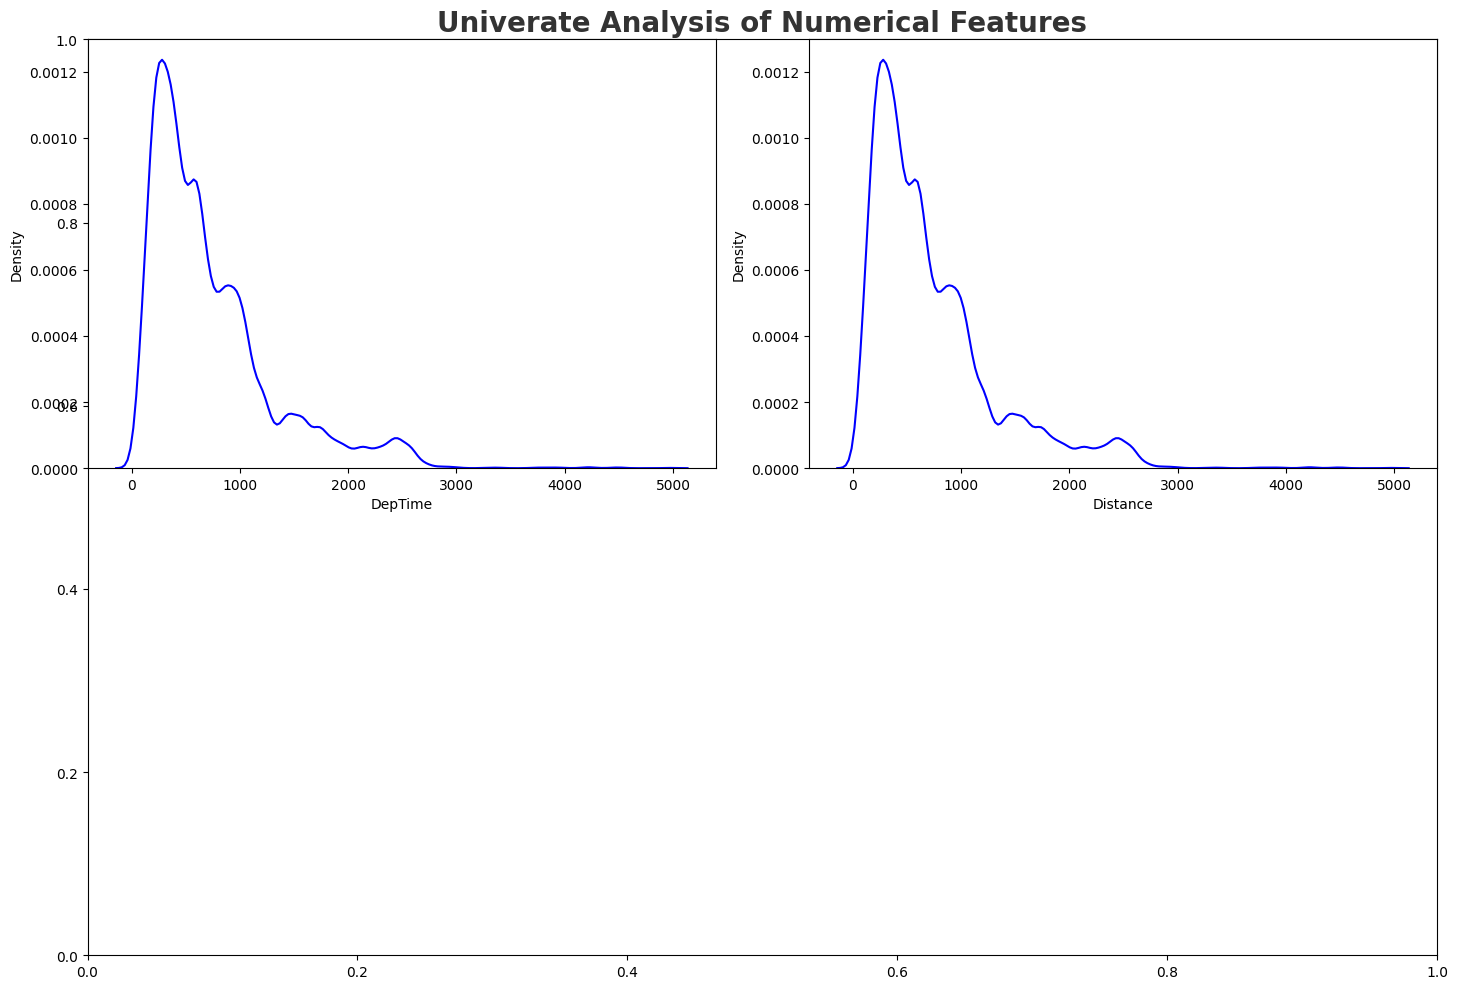

In [13]:

plt.figure(figsize=(15,10))
plt.title("Univerate Analysis of Numerical Features",fontsize=20,fontweight='bold',alpha=0.8,y=1.)

for i in range(0,len(numerical_feature)):
    plt.subplot(2,2,i+1)
    sns.kdeplot(df[numerical_feature[1]],color='blue')
    plt.xlabel(numerical_feature[i])
    plt.tight_layout()




### Statistcis technique

In [14]:

from scipy.stats import chi2_contingency

chi_test=[]

for col in categorical_feature:
    if chi2_contingency(pd.crosstab(df['dep_delayed_15min'],df[col]))[1]<0.05:
        chi_test.append('Reject Null hypothesis')
    else:
        chi_test.append('Fail to reject null hypothesis')

result = pd.DataFrame(data=[categorical_feature,chi_test]).T
result.columns = ['column','Hypothesis Result']
result

,column,Hypothesis Result
0,Month,Reject Null hypothesis
1,DayofMonth,Reject Null hypothesis
2,DayOfWeek,Reject Null hypothesis
3,UniqueCarrier,Reject Null hypothesis
4,Origin,Reject Null hypothesis
5,Dest,Reject Null hypothesis
6,dep_delayed_15min,Reject Null hypothesis



## Month Column

In [15]:

df['Month'].unique()

array(['c-8', 'c-4', 'c-9', 'c-11', 'c-10', 'c-1', 'c-7', 'c-6', 'c-5',
       'c-3', 'c-12', 'c-2'], dtype=object)

In [16]:

df['Month'].value_counts()

,count
Month,
c-8,8830
c-7,8706
c-3,8595
c-5,8543
c-6,8414
c-4,8408
c-10,8405
c-12,8265
c-11,8178



## DayofMonth Column

In [17]:

df['DayofMonth'].unique()

array(['c-21', 'c-20', 'c-2', 'c-25', 'c-7', 'c-3', 'c-27', 'c-29',
       'c-28', 'c-5', 'c-6', 'c-10', 'c-19', 'c-26', 'c-14', 'c-22',
       'c-9', 'c-31', 'c-4', 'c-16', 'c-18', 'c-30', 'c-1', 'c-24',
       'c-15', 'c-17', 'c-8', 'c-12', 'c-13', 'c-11', 'c-23'],
      dtype=object)

In [18]:

df['DayofMonth'].value_counts()

,count
DayofMonth,
c-1,3399
c-20,3380
c-6,3377
c-22,3374
c-14,3366
c-17,3347
c-10,3342
c-27,3330
c-28,3321



### Insight
1. I'll descide to drop the Month,DayofMonth and DayofWeek column also because this column is waste for my project


## DepTime column

In [19]:

df['DepTime'].value_counts()

,count
DepTime,
700,359
600,307
655,249
800,239
1500,237
...,...
2500,1
2447,1
2440,1


In [20]:

df['DepTime'].unique()

array([1934, 1548, 1422, ..., 2530,  219, 2415])


## UniqueCarrier Column

In [21]:

df['UniqueCarrier'].unique()

array(['AA', 'US', 'XE', 'OO', 'WN', 'NW', 'DL', 'OH', 'AS', 'UA', 'MQ',
       'CO', 'EV', 'DH', 'YV', 'F9', 'AQ', 'TZ', 'HP', 'B6', 'FL', 'HA'],
      dtype=object)

In [22]:

df['UniqueCarrier'].value_counts()

,count
UniqueCarrier,
WN,15082
AA,9418
DL,8128
MQ,7443
OO,7390
UA,6876
US,6482
NW,6403
XE,5901



## Origin

In [23]:

df['Origin'].unique()

array(['ATL', 'PIT', 'RDU', 'DEN', 'MDW', 'MEM', 'PBI', 'MSP', 'ONT',
       'BDL', 'PHX', 'LAS', 'DFW', 'DSM', 'CMH', 'ORF', 'SLC', 'CLT',
       'GSO', 'IAD', 'SMF', 'FLL', 'DAL', 'ORD', 'ITO', 'SAN', 'ROA',
       'LGA', 'SFO', 'GSP', 'SEA', 'DAB', 'SJC', 'LIT', 'LAX', 'OAK',
       'COS', 'OKC', 'GRR', 'JFK', 'BOI', 'MCI', 'BWI', 'BHM', 'CRP',
       'BOS', 'SAT', 'PHL', 'STL', 'CIC', 'AUS', 'IAH', 'COD', 'HNL',
       'RNO', 'BNA', 'TPA', 'MIA', 'EVV', 'PNS', 'EWR', 'RSW', 'ANC',
       'SNA', 'AMA', 'CID', 'DTW', 'DCA', 'LGB', 'MAF', 'MFE', 'BMI',
       'PDX', 'IPL', 'GRB', 'FAR', 'HOU', 'MTJ', 'DRO', 'MLU', 'VPS',
       'TUL', 'CVG', 'SBA', 'PWM', 'IDA', 'MCO', 'ACV', 'CHS', 'BGM',
       'MSY', 'OGG', 'CLE', 'MOB', 'CAK', 'FAY', 'SHV', 'TUS', 'IND',
       'CAE', 'PVD', 'ROC', 'MFR', 'VLD', 'ELP', 'RIC', 'MKE', 'SGF',
       'TYS', 'CHO', 'EGE', 'BIS', 'JAN', 'JAX', 'BUF', 'MSO', 'BGR',
       'CEC', 'ICT', 'MYR', 'ALB', 'LIH', 'SBP', 'AEX', 'GNV', 'SAV',
       'BTM', 'BRO',


### Insight
Origin means beginning of the flight


## Dest

In [24]:

df["Dest"].unique()

array(['DFW', 'MCO', 'CLE', 'MEM', 'OMA', 'LGA', 'CVG', 'PSC', 'STL',
       'SEA', 'SJC', 'ORD', 'IAH', 'ATL', 'CMH', 'ILM', 'MSP', 'PHX',
       'AUS', 'SYR', 'LAX', 'HNL', 'ORF', 'MYR', 'PDX', 'CHS', 'SMF',
       'DTW', 'SNA', 'PHL', 'IAD', 'LAS', 'OGG', 'ABI', 'SLC', 'EWR',
       'PVD', 'SFO', 'RDU', 'MDW', 'DAL', 'SAT', 'RNO', 'JAX', 'HRL',
       'JAN', 'ISP', 'TPA', 'JFK', 'FCA', 'PIT', 'CLT', 'BUF', 'OKC',
       'ANC', 'SAN', 'BET', 'FLL', 'SBA', 'GJT', 'DEN', 'MIA', 'BZN',
       'FWA', 'BDL', 'BOI', 'GSO', 'GSP', 'OAK', 'LAN', 'YUM', 'MKE',
       'MQT', 'ONT', 'ELP', 'LBB', 'PBI', 'SJU', 'ACY', 'CAK', 'ABQ',
       'KOA', 'BNA', 'IDA', 'EVV', 'LEX', 'ITO', 'SBP', 'BOS', 'KTN',
       'SGF', 'HOU', 'ALB', 'TUL', 'ABE', 'AMA', 'LIT', 'IND', 'ROA',
       'ROC', 'SAV', 'TOL', 'FAT', 'MCI', 'MSN', 'DCA', 'GRR', 'BUR',
       'AVL', 'MLU', 'ACV', 'RIC', 'COS', 'DAY', 'GRB', 'CRP', 'FNT',
       'ICT', 'TLH', 'XNA', 'CRW', 'GEG', 'HPN', 'VPS', 'CMI', 'LNK',
       'EYW', 'BWI',

In [25]:

df["Dest"].value_counts()

,count
Dest,
ATL,5795
ORD,4933
DFW,4337
LAX,3205
IAH,3056
...,...
LWB,1
TEX,1
ACK,1



### Insight
Dest column is the Destination of the flight


## Distance column

In [26]:

df["Distance"].unique()

array([ 732,  834,  416, ..., 2242,  536, 1198])

In [27]:

df["Distance"].value_counts()

,count
Distance,
214,584
109,564
337,516
370,504
224,439
...,...
792,1
2024,1
1102,1



## dep_delayed_15min columns

In [28]:

df["dep_delayed_15min"].unique()

array(['N', 'Y'], dtype=object)

In [29]:

df["dep_delayed_15min"].value_counts()

,count
dep_delayed_15min,
N,80956
Y,19044



## Ploting the graphs

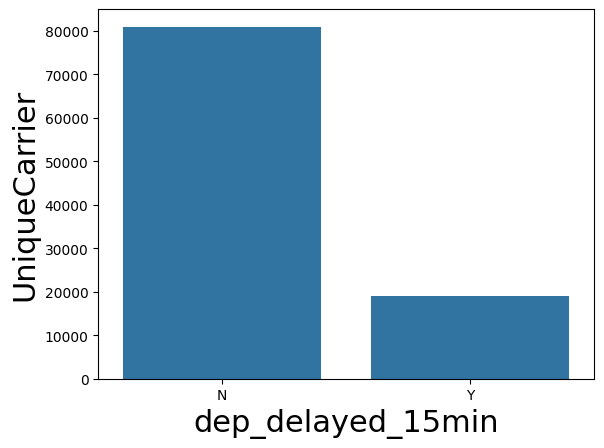

In [30]:

unique_dep = df.groupby(['dep_delayed_15min'])['UniqueCarrier'].count().to_frame()
sns.barplot(x='dep_delayed_15min',y='UniqueCarrier',data=unique_dep)
plt.xlabel("dep_delayed_15min",size=22)
plt.ylabel("UniqueCarrier",size=22)
plt.show()


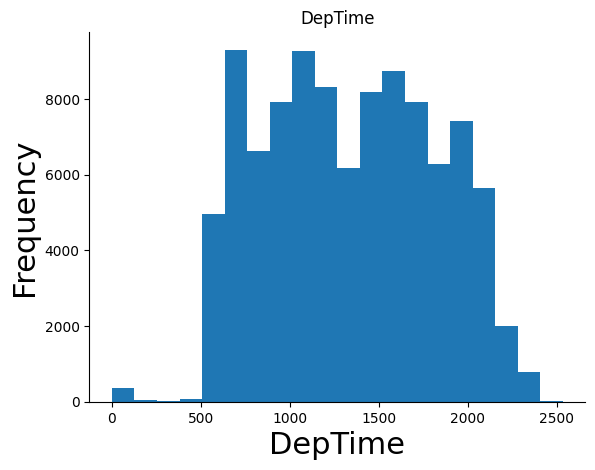

In [46]:

df['DepTime'].plot(kind='hist', bins=20, title='DepTime')
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.xlabel('DepTime',size=22)
plt.ylabel('Frequency',size=22)
plt.show()

### Insight:
- DepTime feature is look like a uniform distribution

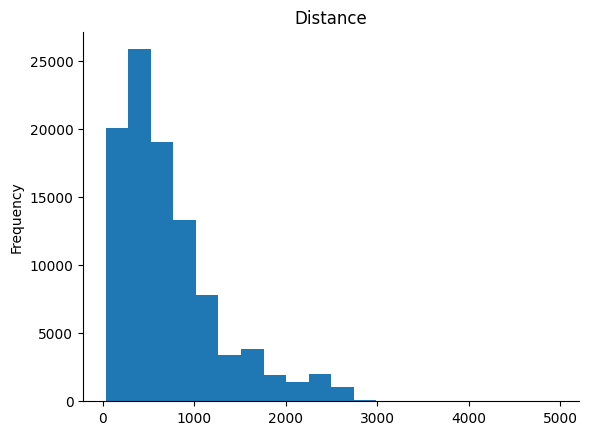

In [42]:
df['Distance'].plot(kind='hist', bins=20, title='Distance')
plt.gca().spines[['top', 'right',]].set_visible(False)

### Insight:
- Distance Column is left skewed

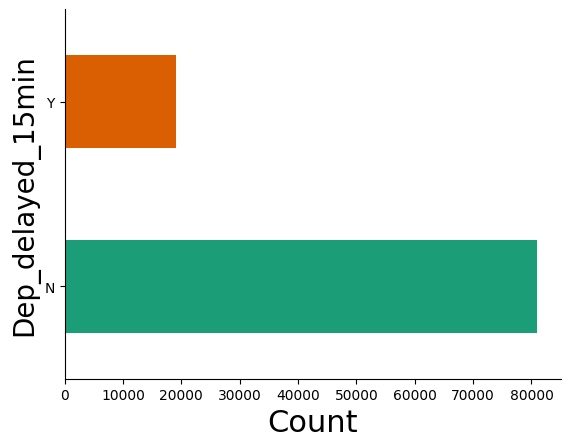

In [45]:

df.groupby('dep_delayed_15min').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.xlabel('Count',size=22)
plt.ylabel('Dep_delayed_15min',size=20)
plt.show()

### Insight:
- N is dominating the Y category in the dataset

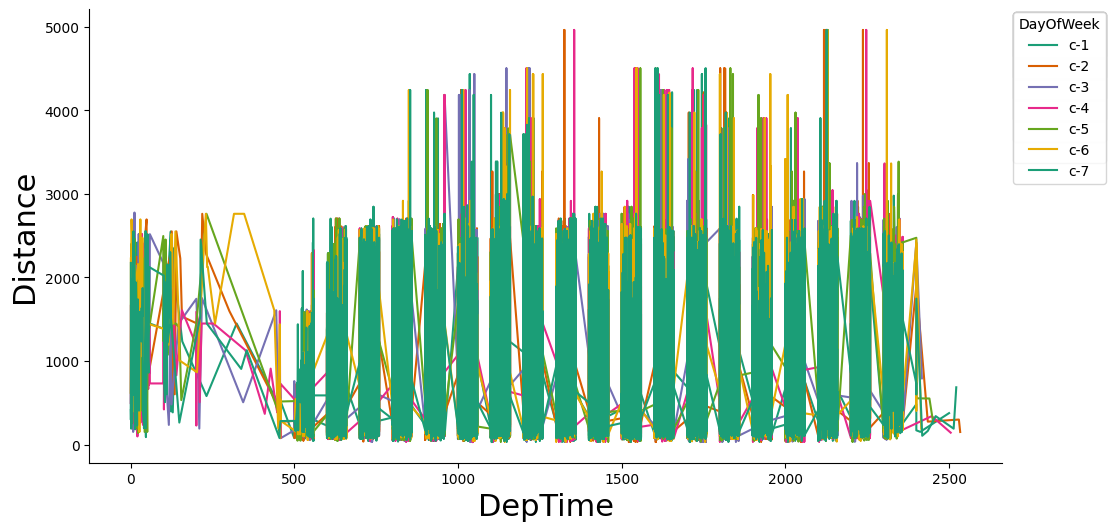

In [48]:
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['DepTime']
  ys = series['Distance']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('DepTime', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('DayOfWeek')):
  _plot_series(series, series_name, i)
  fig.legend(title='DayOfWeek', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('DepTime',size=22)
_ = plt.ylabel('Distance',size=22)
plt.show()

### DepTime vs Count



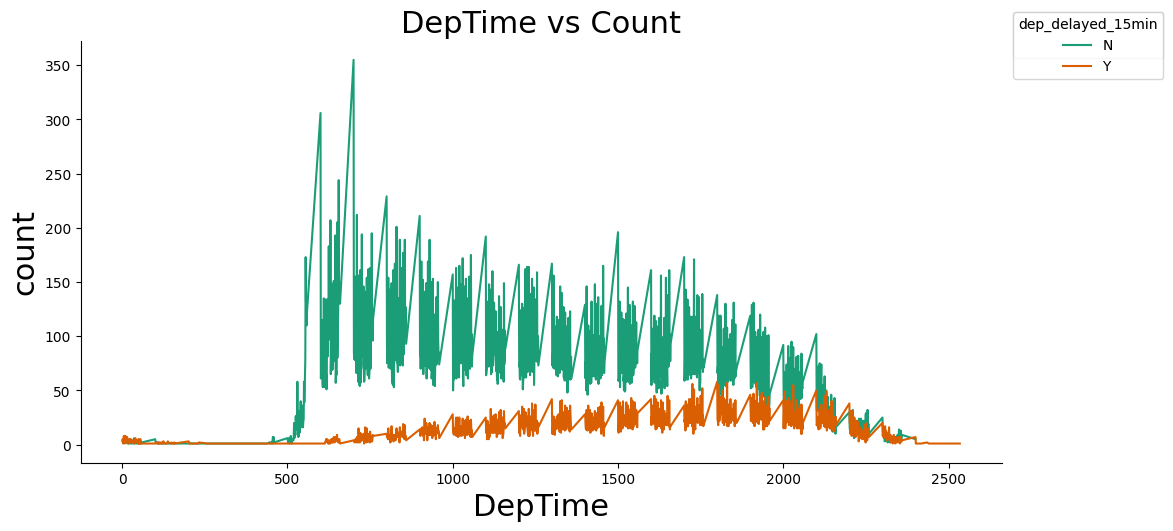

In [50]:
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['DepTime']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'DepTime'}, axis=1)
              .sort_values('DepTime', ascending=True))
  xs = counted['DepTime']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('DepTime', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('dep_delayed_15min')):
  _plot_series(series, series_name, i)
  fig.legend(title='dep_delayed_15min', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('DepTime',size=22)
plt.title('DepTime vs Count',size=22)
_ = plt.ylabel('count',size=22)

### DayOfWeek vs dep_delayed_15min

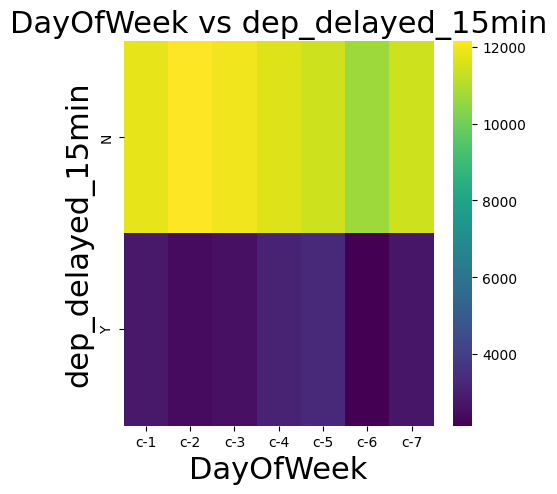

In [52]:
plt.subplots(figsize=(5, 5))
df_2dhist = pd.DataFrame({
    x_label: grp['dep_delayed_15min'].value_counts()
    for x_label, grp in df.groupby('DayOfWeek')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('DayOfWeek',size=22)
_ = plt.ylabel('dep_delayed_15min',size=22)
plt.title('DayOfWeek vs dep_delayed_15min',size=22)
plt.show()

### DayOfWeek vs DepTime

<ipython-input-54-08e25ffe9b9b>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df, x='DepTime', y='DayOfWeek', inner='box', palette='Dark2')


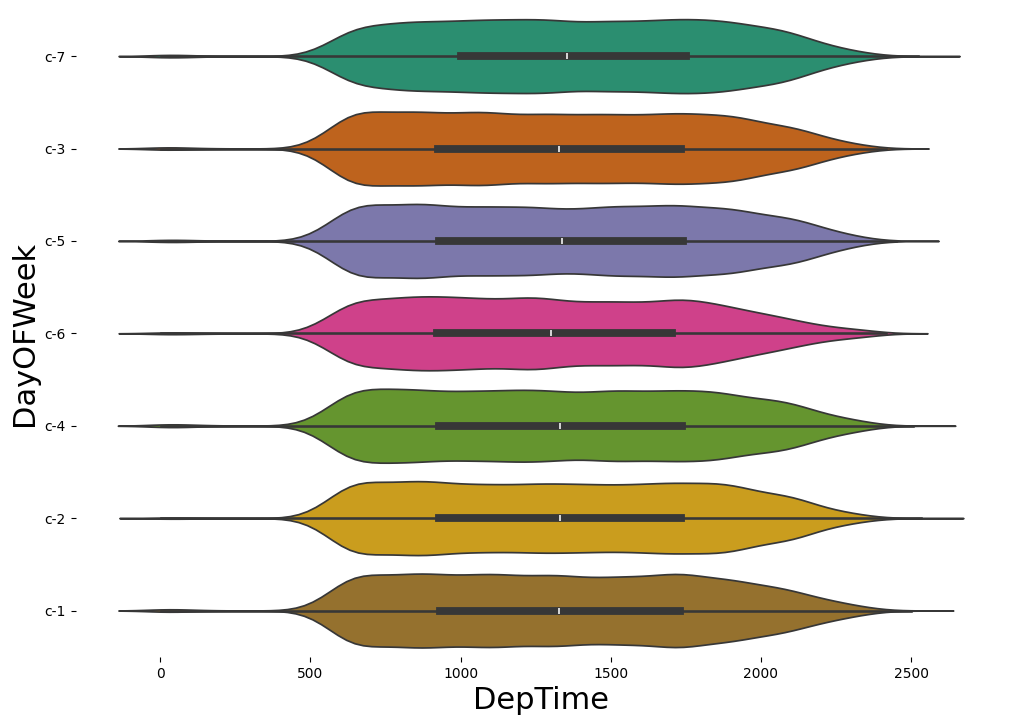

In [54]:

figsize = (12, 1.2 * len(df['DayOfWeek'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df, x='DepTime', y='DayOfWeek', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)
plt.xlabel('DepTime',size=22)
plt.ylabel('DayOFWeek',size=22)
plt.show()

### dep_delayed_15min vs DepTime


<ipython-input-57-a983bacac7fe>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df, x='DepTime', y='dep_delayed_15min', inner='box', palette='Dark2')


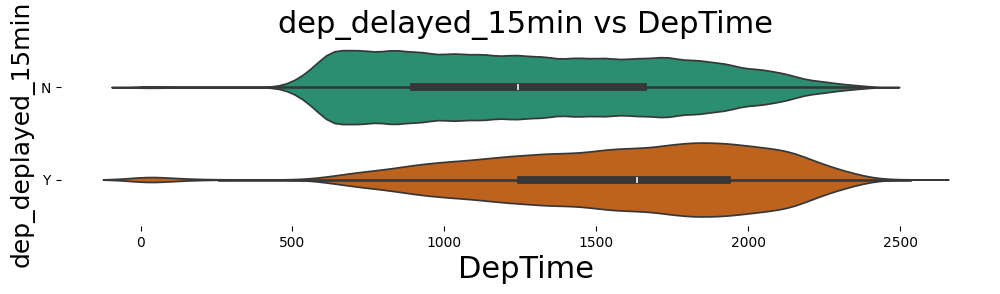

In [57]:
figsize = (12, 1.2 * len(df['dep_delayed_15min'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df, x='DepTime', y='dep_delayed_15min', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)
plt.xlabel('DepTime',size=22)
plt.ylabel('dep_deplayed_15min',size=18)
plt.title('dep_delayed_15min vs DepTime',size=22)
plt.show()

### DayOfWeek vs Distance

<ipython-input-58-9d500f8c9043>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df, x='Distance', y='DayOfWeek', inner='box', palette='Dark2')


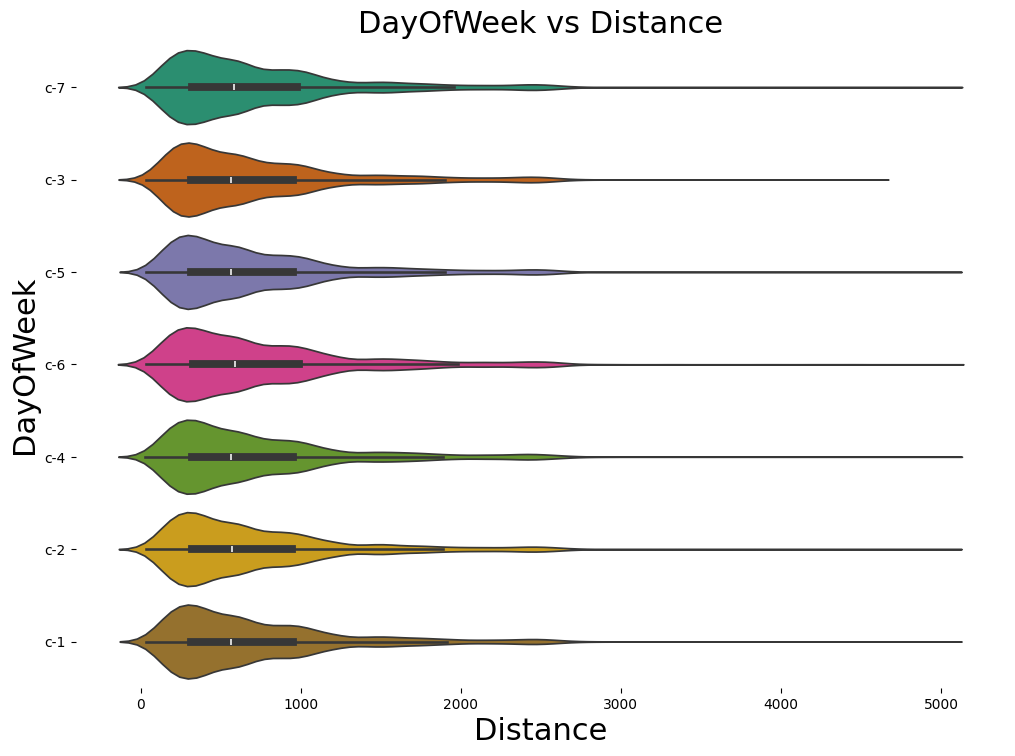

In [58]:
figsize = (12, 1.2 * len(df['DayOfWeek'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df, x='Distance', y='DayOfWeek', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)
plt.title("DayOfWeek vs Distance",size=22)
plt.ylabel('DayOfWeek',size=22)
plt.xlabel('Distance',size=22)
plt.show()


## Feature Enginnering


### Show Top 5 Rows

In [31]:

df.head()


,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min
0,c-8,c-21,c-7,1934,AA,ATL,DFW,732,N
1,c-4,c-20,c-3,1548,US,PIT,MCO,834,N
2,c-9,c-2,c-5,1422,XE,RDU,CLE,416,N
3,c-11,c-25,c-6,1015,OO,DEN,MEM,872,N
4,c-10,c-7,c-6,1828,WN,MDW,OMA,423,Y



### Origin columns means in beginning of the airplane

- Choose a threshold.
- Threshold is 500
- Converting before the threshold "Others Airport"

In [59]:

count_origin = df['Origin'].value_counts()
origin_keep = count_origin[count_origin>=500].index
origin_keep

Index(['ATL', 'ORD', 'DFW', 'LAX', 'IAH', 'DEN', 'PHX', 'LAS', 'CVG', 'EWR',
       'SLC', 'DTW', 'MSP', 'SFO', 'LGA', 'BOS', 'MCO', 'PHL', 'CLT', 'SEA',
       'IAD', 'BWI', 'JFK', 'MDW', 'DCA', 'SAN', 'CLE', 'TPA', 'OAK', 'FLL',
       'MIA', 'STL', 'BNA', 'RDU', 'SJC', 'PDX', 'HOU', 'MCI', 'HNL', 'SMF',
       'SNA', 'PIT', 'MEM', 'DAL', 'AUS', 'SAT', 'IND', 'ONT', 'CMH', 'ABQ'],
      dtype='object', name='Origin')

In [60]:

def function_origin(text):
    if text in ['ATL', 'ORD', 'DFW', 'LAX', 'IAH', 'DEN', 'PHX', 'LAS', 'CVG', 'EWR',
       'SLC', 'DTW', 'MSP', 'SFO', 'LGA', 'BOS', 'MCO', 'PHL', 'CLT', 'SEA',
       'IAD', 'BWI', 'JFK', 'MDW', 'DCA', 'SAN', 'CLE', 'TPA', 'OAK', 'FLL',
       'MIA', 'STL', 'BNA', 'RDU', 'SJC', 'PDX', 'HOU', 'MCI', 'HNL', 'SMF',
       'SNA', 'PIT', 'MEM', 'DAL', 'AUS', 'SAT', 'IND', 'ONT', 'CMH', 'ABQ']:
        return text
    else:
        return "Others Airport"

df['Origin'] = df['Origin'].apply(function_origin)


In [61]:

df['Origin'].unique()

array(['ATL', 'PIT', 'RDU', 'DEN', 'MDW', 'MEM', 'Others Airport', 'MSP',
       'ONT', 'PHX', 'LAS', 'DFW', 'CMH', 'SLC', 'CLT', 'IAD', 'SMF',
       'FLL', 'DAL', 'ORD', 'SAN', 'LGA', 'SFO', 'SEA', 'SJC', 'LAX',
       'OAK', 'JFK', 'MCI', 'BWI', 'BOS', 'SAT', 'PHL', 'STL', 'AUS',
       'IAH', 'HNL', 'BNA', 'TPA', 'MIA', 'EWR', 'SNA', 'DTW', 'DCA',
       'PDX', 'HOU', 'CVG', 'MCO', 'CLE', 'IND', 'ABQ'], dtype=object)


### Dest columns means in destination of the airplane
- Choose a threshold.
- Threshold is 500
- Converting before the threshold "Others Airport"

In [62]:

df['Dest'].value_counts()[:50]

,count
Dest,
ATL,5795
ORD,4933
DFW,4337
LAX,3205
IAH,3056
DEN,2866
PHX,2749
LAS,2475
CVG,2434


In [63]:

count_dest = df['Dest'].value_counts()
dest_keep = count_dest[count_dest>=500].index
dest_keep

Index(['ATL', 'ORD', 'DFW', 'LAX', 'IAH', 'DEN', 'PHX', 'LAS', 'CVG', 'EWR',
       'SLC', 'DTW', 'MSP', 'SFO', 'BOS', 'LGA', 'MCO', 'CLT', 'PHL', 'IAD',
       'SEA', 'JFK', 'BWI', 'DCA', 'MDW', 'SAN', 'CLE', 'TPA', 'OAK', 'SJC',
       'FLL', 'MIA', 'STL', 'RDU', 'BNA', 'MCI', 'PDX', 'SMF', 'HOU', 'SNA',
       'HNL', 'PIT', 'DAL', 'SAT', 'MEM', 'AUS', 'IND', 'ABQ', 'BDL'],
      dtype='object', name='Dest')

In [64]:

def function_dest(text):
    if text in ['ATL', 'ORD', 'DFW', 'LAX', 'IAH', 'DEN', 'PHX', 'LAS', 'CVG', 'EWR',
       'SLC', 'DTW', 'MSP', 'SFO', 'BOS', 'LGA', 'MCO', 'CLT', 'PHL', 'IAD',
       'SEA', 'JFK', 'BWI', 'DCA', 'MDW', 'SAN', 'CLE', 'TPA', 'OAK', 'SJC',
       'FLL', 'MIA', 'STL', 'RDU', 'BNA', 'MCI', 'PDX', 'SMF', 'HOU', 'SNA',
       'HNL', 'PIT', 'DAL', 'SAT', 'MEM', 'AUS', 'IND', 'ABQ', 'BDL']:
        return text

    else:
        return "Other Airports"

df['Dest'] = df['Dest'].apply(function_dest)

In [65]:

df['Dest'].unique()

array(['DFW', 'MCO', 'CLE', 'MEM', 'Other Airports', 'LGA', 'CVG', 'STL',
       'SEA', 'SJC', 'ORD', 'IAH', 'ATL', 'MSP', 'PHX', 'AUS', 'LAX',
       'HNL', 'PDX', 'SMF', 'DTW', 'SNA', 'PHL', 'IAD', 'LAS', 'SLC',
       'EWR', 'SFO', 'RDU', 'MDW', 'DAL', 'SAT', 'TPA', 'JFK', 'PIT',
       'CLT', 'SAN', 'FLL', 'DEN', 'MIA', 'BDL', 'OAK', 'ABQ', 'BNA',
       'BOS', 'HOU', 'IND', 'MCI', 'DCA', 'BWI'], dtype=object)


### UniqueCarrier column

In [66]:

df['UniqueCarrier'].value_counts()[:50]

,count
UniqueCarrier,
WN,15082
AA,9418
DL,8128
MQ,7443
OO,7390
UA,6876
US,6482
NW,6403
XE,5901


In [67]:

df['UniqueCarrier'].unique()

array(['AA', 'US', 'XE', 'OO', 'WN', 'NW', 'DL', 'OH', 'AS', 'UA', 'MQ',
       'CO', 'EV', 'DH', 'YV', 'F9', 'AQ', 'TZ', 'HP', 'B6', 'FL', 'HA'],
      dtype=object)


### Month column

In [68]:

df['Month'] = df['Month'].str.split('-').str[1].astype('int64')

In [69]:

df['Month']

,Month
0,8
1,4
2,9
3,11
4,10
...,...
99995,5
99996,1
99997,1
99998,4



### Day of Month column

In [70]:

df['DayofMonth']

,DayofMonth
0,c-21
1,c-20
2,c-2
3,c-25
4,c-7
...,...
99995,c-4
99996,c-18
99997,c-24
99998,c-27


In [71]:

df['DayofMonth'] = df['DayofMonth'].str.split('-').str[1].astype('int64')

In [72]:

df['DayofMonth']

,DayofMonth
0,21
1,20
2,2
3,25
4,7
...,...
99995,4
99996,18
99997,24
99998,27



### Extract all the important feature

In [73]:

df2 = df[['Month','DayofMonth','DepTime','UniqueCarrier','Origin','Dest','Distance','dep_delayed_15min']]



### Show Top 5 rows

In [74]:

df2.head()

,Month,DayofMonth,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min
0,8,21,1934,AA,ATL,DFW,732,N
1,4,20,1548,US,PIT,MCO,834,N
2,9,2,1422,XE,RDU,CLE,416,N
3,11,25,1015,OO,DEN,MEM,872,N
4,10,7,1828,WN,MDW,Other Airports,423,Y


In [75]:

X = df2.drop(['dep_delayed_15min'],axis=1)
y = df2['dep_delayed_15min']

X

,Month,DayofMonth,DepTime,UniqueCarrier,Origin,Dest,Distance
0,8,21,1934,AA,ATL,DFW,732
1,4,20,1548,US,PIT,MCO,834
2,9,2,1422,XE,RDU,CLE,416
3,11,25,1015,OO,DEN,MEM,872
4,10,7,1828,WN,MDW,Other Airports,423
...,...,...,...,...,...,...,...
99995,5,4,1618,OO,SFO,Other Airports,199
99996,1,18,804,CO,EWR,Other Airports,884
99997,1,24,1901,NW,DTW,IAH,1076
99998,4,27,1515,MQ,DFW,Other Airports,140



### Using the OneHotEncoder technique on this feature:
- Origin
- Dest
- UniqueCarrier

In [76]:

ohe_origin = OneHotEncoder()
origin_array = ohe_origin.fit_transform(X[['Origin']]).toarray()
origin_array


array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [77]:

with open('ohe_origin.pkl','wb') as file:
  pickle.dump(ohe_origin,file)

In [78]:

ohe_dest = OneHotEncoder()
dest_array = ohe_dest.fit_transform(X[['Dest']]).toarray()
dest_array


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [79]:

with open("ohe_dest.pkl",'wb') as file:
  pickle.dump(ohe_dest,file)

In [80]:

ohe_unique = OneHotEncoder()
unique_array = ohe_unique.fit_transform(X[['UniqueCarrier']]).toarray()
unique_array


array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]])

In [81]:
with open("ohe_unique.pkl",'wb') as file:
  pickle.dump(ohe_unique,file)


### Drop the waste feature in the "x" data frame

In [82]:

X.drop(['Dest','Origin',"UniqueCarrier"],axis=1,inplace=True)


### Using the horizontal stack technique inside in the numpy library

In [83]:

final_x = np.hstack((X,origin_array,dest_array))
final_x

array([[8.000e+00, 2.100e+01, 1.934e+03, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [4.000e+00, 2.000e+01, 1.548e+03, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [9.000e+00, 2.000e+00, 1.422e+03, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       ...,
       [1.000e+00, 2.400e+01, 1.901e+03, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [4.000e+00, 2.700e+01, 1.515e+03, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [1.100e+01, 1.700e+01, 1.800e+03, ..., 0.000e+00, 0.000e+00,
        0.000e+00]])


### Using the SMOTE technique

In [84]:

# smote = SMOTE(sampling_strategy='auto',random_state=42)
# x_resample,y_resample = smote.fit_resample(final_x,y)


In [85]:
from imblearn.combine import SMOTEENN,SMOTETomek

smt = SMOTEENN(random_state=42,sampling_strategy='minority')
x_res,y_res = smt.fit_resample(final_x,y)
x_res

array([[1.10000000e+01, 2.50000000e+01, 1.01500000e+03, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.00000000e+00, 2.70000000e+01, 7.54000000e+02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [4.00000000e+00, 2.90000000e+01, 6.35000000e+02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [3.36180099e+00, 1.34472040e+01, 1.12355280e+03, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.11207478e+01, 1.28792522e+01, 1.90012561e+03, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [3.43854082e+00, 1.69269099e+01, 1.12092691e+03, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

In [86]:
print(f"Shape of the resample:{x_res.shape}")

Shape of the resample:(102732, 105)


In [87]:
x_res

array([[1.10000000e+01, 2.50000000e+01, 1.01500000e+03, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.00000000e+00, 2.70000000e+01, 7.54000000e+02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [4.00000000e+00, 2.90000000e+01, 6.35000000e+02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [3.36180099e+00, 1.34472040e+01, 1.12355280e+03, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.11207478e+01, 1.28792522e+01, 1.90012561e+03, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [3.43854082e+00, 1.69269099e+01, 1.12092691e+03, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

In [88]:

print(f"Shape of the resample:{y_res.shape}")

Shape of the resample:(102732,)


In [89]:
y_res

,dep_delayed_15min
0,N
1,N
2,N
3,N
4,N
...,...
102727,Y
102728,Y
102729,Y
102730,Y



### Count

In [90]:

y_res.value_counts()

,count
dep_delayed_15min,
Y,60880
N,41852



### Now using the label encoder on the target column

In [91]:

le = LabelEncoder()
y_res = le.fit_transform(y_res)
y_res


array([0, 0, 0, ..., 1, 1, 1])

In [92]:

le.classes_

array(['N', 'Y'], dtype=object)


### Insight

1. N is 0

2. Y is 1



### Splitting the dataset

In [93]:

x_train,x_test,y_train,y_test = train_test_split(x_res,y_res,test_size=0.2,random_state=42)
x_train

array([[   4.43157949,   14.48947177,  831.29473848, ...,    0.        ,
           0.        ,    0.        ],
       [  10.        ,   13.        , 1454.        , ...,    0.        ,
           0.        ,    0.        ],
       [  11.        ,   26.        , 1007.        , ...,    0.        ,
           0.        ,    0.        ],
       ...,
       [   6.46401616,   17.14393534, 2152.17614548, ...,    0.        ,
           0.        ,    0.        ],
       [   7.        ,   16.        ,  931.        , ...,    0.        ,
           0.        ,    0.        ],
       [   9.        ,    6.        , 2157.        , ...,    0.        ,
           0.        ,    0.        ]])

In [94]:

y_test

array([1, 1, 1, ..., 0, 1, 1])


### Using the StandardScaler technique

In [95]:

scaler = StandardScaler()
x_train_scaler = scaler.fit_transform(x_train)
x_train_scaler

array([[-0.67364418, -0.17457474, -1.17270792, ..., -0.08884898,
        -0.10527413, -0.1217484 ],
       [ 1.07337521, -0.35211636,  0.0625383 , ..., -0.08884898,
        -0.10527413, -0.1217484 ],
       [ 1.38711218,  1.19745384, -0.8241654 , ..., -0.08884898,
        -0.10527413, -0.1217484 ],
       ...,
       [-0.03599365,  0.14183123,  1.4474944 , ..., -0.08884898,
        -0.10527413, -0.1217484 ],
       [ 0.13216429,  0.00547676, -0.97492487, ..., -0.08884898,
        -0.10527413, -0.1217484 ],
       [ 0.75963824, -1.18650032,  1.45706337, ..., -0.08884898,
        -0.10527413, -0.1217484 ]])

In [96]:

x_test_scaler = scaler.transform(x_test)
x_test_scaler

array([[-0.94895363, -0.12660926,  1.40680133, ..., -0.08884898,
        -0.10527413, -0.1217484 ],
       [-1.08219833, -0.15997948,  1.75378265, ..., -0.08884898,
        -0.10527413, -0.1217484 ],
       [ 1.26930777,  0.7955686 ,  0.2075976 , ..., -0.08884898,
        -0.10527413, -0.1217484 ],
       ...,
       [-1.1227836 ,  0.48226759, -1.12370066, ..., -0.08884898,
        -0.10527413, -0.1217484 ],
       [ 0.66974761, -1.61217457,  0.59048247, ..., -0.08884898,
        -0.10527413, -0.1217484 ],
       [-0.79789704, -1.23163777,  0.78513649, ..., -0.08884898,
        -0.10527413, -0.1217484 ]])

In [97]:
with open('scaler.pkl','wb') as file:
  pickle.dump(scaler,file)


## Start building the model


### Firstly using the Deep learning technique(ANN)

In [67]:

model = Sequential()
model.add(Dense(64,activation = 'relu',input_shape=(x_train_scaler.shape[1],),kernel_initializer='glorot_normal'))
model.add(BatchNormalization())
model.add(Dense(128,activation = 'relu',kernel_initializer='glorot_normal'))
model.add(BatchNormalization())
model.add(Dense(264,activation = 'relu',kernel_initializer='glorot_normal'))
model.add(BatchNormalization())
model.add(Dense(512,activation = 'relu',kernel_initializer='glorot_normal'))
#model.add(BatchNormalization())
#model.add(Dense(624,activation = 'relu',kernel_initializer='normal_uniform'))
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',metrics=['accuracy'],optimizer='adam')
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           6,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 264)                 │          34,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 264)                 │           1,056 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 512)                 │         135,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 187,177 (731.16 KB)

 Trainable params: 186,265 (727.60 KB)

 Non-trainable params: 912 (3.56 KB)


### Intializing the early stopping method

In [68]:

early_stopping = EarlyStopping(monitor='val_loss',
                               patience=5,
                               restore_best_weights=True,
                               verbose=1)

reduce = ReduceLROnPlateau(monitor='val_loss',
                  patience=3,
                  factor=0.2,
                  min_lr=1e-6,
                  verbose=1)



### Fitting the data in the model

In [69]:

history = model.fit(x_train_scaler,y_train,validation_data=(x_test_scaler,y_test),epochs=50,verbose=True,callbacks=[early_stopping,reduce])


Epoch 1/50
2569/2569 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.7441 - loss: 0.5143 - val_accuracy: 0.8126 - val_loss: 0.3875 - learning_rate: 0.0010
Epoch 2/50
2569/2569 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.8164 - loss: 0.3840 - val_accuracy: 0.8354 - val_loss: 0.3420 - learning_rate: 0.0010
Epoch 3/50
2569/2569 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8293 - loss: 0.3582 - val_accuracy: 0.8358 - val_loss: 0.3698 - learning_rate: 0.0010
Epoch 4/50
2569/2569 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8363 - loss: 0.3425 - val_accuracy: 0.8482 - val_loss: 0.3248 - learning_rate: 0.0010
Epoch 5/50
2569/2569 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8396 - loss: 0.3361 - val_accuracy: 0.8512 - val_loss: 0.3090 - learning_rate: 0.0010
Epoch 6/50
2569/2569 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8455 - loss: 0.3221 - val_accuracy: 0.8512 - val_loss: 0.3097 - learning_rate: 0.0010
Epoch 7/50
2569/2569 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.848

## For loss

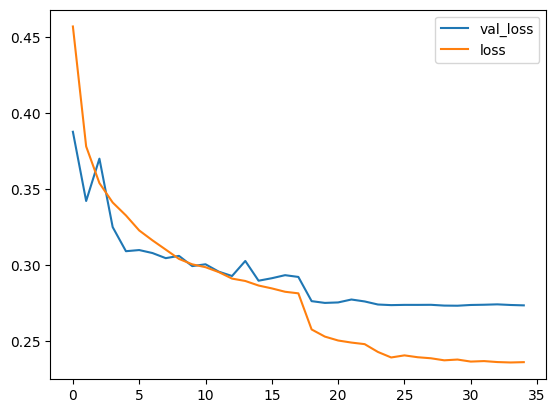

In [77]:
plt.plot(history.history['val_loss'],label='val_loss')
plt.plot(history.history['loss'],label='loss')
plt.legend()
plt.show()

## For accuracy

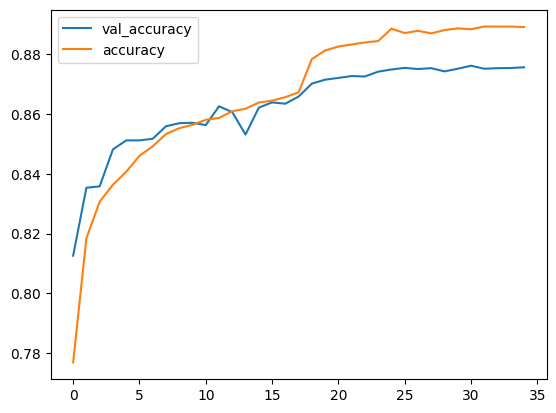

In [78]:

plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.plot(history.history['accuracy'],label='accuracy')
plt.legend()
plt.show()

## In Deep learning technique
- Training accuracy is 88%
- Testing accuracy is 87%


### Here using the ML technique


### Intializing the metrics

In [ ]:

def metrics(true,predicted):
    acc = accuracy_score(true,predicted)
    f1 = f1_score(true,predicted)
    precision = precision_score(true, predicted) # Calculate Precision
    recall = recall_score(true, predicted)  # Calculate Recall
    roc_auc = roc_auc_score(true, predicted) #Calculate Roc
    return acc, f1 , precision, recall, roc_auc

In [ ]:

models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
     "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(),
     "CatBoosting Classifier": CatBoostClassifier(verbose=False),
     #"Support Vector Classifier": SVC(),
    "AdaBoost Classifier": AdaBoostClassifier()

}

In [ ]:

def evaluate_models(X, y, models):
    '''
    This function takes in X and y and models dictionary as input
    It splits the data into Train Test split
    Iterates through the given model dictionary and evaluates the metrics
    Returns: Dataframe which contains report of all models metrics with cost
    '''
    # separate dataset into train and test
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

    models_list = []
    accuracy_list = []
    auc= []

    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train, y_train) # Train model

        # Make predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Training set performance
        model_train_accuracy, model_train_f1,model_train_precision,\
        model_train_recall,model_train_rocauc_score=metrics(y_train ,y_train_pred)


        # Test set performance
        model_test_accuracy,model_test_f1,model_test_precision,\
        model_test_recall,model_test_rocauc_score=metrics(y_test, y_test_pred)

        print(list(models.keys())[i])
        models_list.append(list(models.keys())[i])

        print('Model performance for Training set')
        print("- Accuracy: {:.4f}".format(model_train_accuracy))
        print('- F1 score: {:.4f}'.format(model_train_f1))
        print('- Precision: {:.4f}'.format(model_train_precision))
        print('- Recall: {:.4f}'.format(model_train_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

        print('----------------------------------')

        print('Model performance for Test set')
        print('- Accuracy: {:.4f}'.format(model_test_accuracy))
        accuracy_list.append(model_test_accuracy)
        print('- F1 score: {:.4f}'.format(model_test_f1))
        print('- Precision: {:.4f}'.format(model_test_precision))
        print('- Recall: {:.4f}'.format(model_test_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))
        auc.append(model_test_rocauc_score)
        print('='*35)
        print('\n')

    report=pd.DataFrame(list(zip(models_list, accuracy_list)), columns=['Model Name', 'Accuracy']).sort_values(by=['Accuracy'], ascending=False)

    return report

In [ ]:

base_model_report = evaluate_models(X=x_res,y=y_res,models=models)

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9073
- F1 score: 0.9201
- Precision: 0.9440
- Recall: 0.8973
- Roc Auc Score: 0.9096


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.8701
- F1 score: 0.8903
- Precision: 0.8935
- Recall: 0.8872
- Roc Auc Score: 0.8661


Gradient Boosting
Model performance for Training set
- Accuracy: 0.8656
- F1 score: 0.8878
- Precision: 0.8777
- Recall: 0.8981
- Roc Auc Score: 0.8582
----------------------------------
Model performance for Test set
- Accuracy: 0.8616
- F1 score: 0.8848
- Precision: 0.8762
- Recall: 0.8935
- Roc Auc Score: 0.8542




C:\Users\iamda\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
Model performance for Training set
- Accuracy: 0.7381
- F1 score: 0.7861
- Precision: 0.7612
- Recall: 0.8127
- Roc Auc Score: 0.7213
----------------------------------
Model performance for Test set
- Accuracy: 0.7419
- F1 score: 0.7901
- Precision: 0.7649
- Recall: 0.8171
- Roc Auc Score: 0.7244


K-Neighbors Classifier
Model performance for Training set
- Accuracy: 0.9636
- F1 score: 0.9699
- Precision: 0.9501
- Recall: 0.9905
- Roc Auc Score: 0.9575
----------------------------------
Model performance for Test set
- Accuracy: 0.9285
- F1 score: 0.9421
- Precision: 0.9089
- Recall: 0.9778
- Roc Auc Score: 0.9170


XGBClassifier
Model performance for Training set
- Accuracy: 0.9182
- F1 score: 0.9285
- Precision: 0.9631
- Recall: 0.8962
- Roc Auc Score: 0.9232
----------------------------------
Model performance for Test set
- Accuracy: 0.9021
- F1 score: 0.9145
- Precision: 0.9514
- Recall: 0.8803
- Roc Auc Score: 0.9072


CatBoosting Classifier
Model performance

C:\Users\iamda\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost Classifier
Model performance for Training set
- Accuracy: 0.8211
- F1 score: 0.8542
- Precision: 0.8255
- Recall: 0.8848
- Roc Auc Score: 0.8067
----------------------------------
Model performance for Test set
- Accuracy: 0.8206
- F1 score: 0.8542
- Precision: 0.8262
- Recall: 0.8843
- Roc Auc Score: 0.8057




In [ ]:

base_model_report

,Model Name,Accuracy
4,K-Neighbors Classifier,0.928505
0,Random Forest,0.907286
6,CatBoosting Classifier,0.904804
5,XGBClassifier,0.902127
1,Decision Tree,0.870054
2,Gradient Boosting,0.861634
7,AdaBoost Classifier,0.820558
3,Logistic Regression,0.741909



### Top 3 Model

1. K-Neighbors Classifier

2. Random Forest

3. CatBoostingClassifier


### Performing the bayesian search with the optuna library

In [ ]:

import optuna

In [ ]:
def objective(trial):
    # Hyperparameters to optimize
    n_neighbors = trial.suggest_int("n_neighbors", 3, 50)  # Number of neighbors
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])  # Weighting scheme
    metric = trial.suggest_categorical("metric", ["euclidean", "manhattan", "minkowski"])  # Distance metric

    # Create the KNN model
    model = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, metric=metric)

    # Perform cross-validation
    score = cross_val_score(model, x_res, y_res, cv=3, scoring='accuracy',n_jobs=-1).mean()

    return score  # Return accuracy score


In [ ]:

# Run Bayesian Optimization
study2 = optuna.create_study(direction="maximize")
study2.optimize(objective, n_trials=20)

# Print best hyperparameters
print("Best parameters:", study2.best_params)


[I 2025-02-08 21:16:08,266] A new study created in memory with name: no-name-aa48b7c4-8fcf-45bf-baab-d79f871a107b
[I 2025-02-08 21:17:29,936] Trial 0 finished with value: 0.8169606354397851 and parameters: {'n_neighbors': 22, 'weights': 'uniform', 'metric': 'minkowski'}. Best is trial 0 with value: 0.8169606354397851.
[I 2025-02-08 21:18:42,055] Trial 1 finished with value: 0.7894521668029436 and parameters: {'n_neighbors': 36, 'weights': 'uniform', 'metric': 'minkowski'}. Best is trial 0 with value: 0.8169606354397851.
[I 2025-02-08 21:19:51,790] Trial 2 finished with value: 0.8720262430401432 and parameters: {'n_neighbors': 25, 'weights': 'distance', 'metric': 'minkowski'}. Best is trial 2 with value: 0.8720262430401432.
[I 2025-02-08 21:21:00,115] Trial 3 finished with value: 0.8561597165440175 and parameters: {'n_neighbors': 37, 'weights': 'distance', 'metric': 'minkowski'}. Best is trial 2 with value: 0.8720262430401432.
[I 2025-02-08 21:22:08,589] Trial 4 finished with value: 0.7

Best parameters: {'n_neighbors': 3, 'weights': 'distance', 'metric': 'manhattan'}



### Best Model is KNeighborsClassifier

In [ ]:

best_param_knearst = study2.best_params
knn = KNeighborsClassifier(**best_param_knearst)
knn.fit(x_train,y_train)
y_pred = knn.predict(x_test)
print(f"KNeighborsClassifier: {accuracy_score(y_test,y_pred)}")

KNeighborsClassifier: 0.962816956246654



# In ML technique best accuracy is 96%
- Algorithm is KNeighbors

In [ ]:
import pickle

with open('knn.pkl','wb') as file:
    pickle.dump(knn,file)

# Comparison:

- I performed both machine learning and deep learning techniques to<br>
achieve the best accuracy. The best model in machine learning was <br>
the K-Neighbors algorithm.
<br>
- The accuracy of the <b>machine learning model was 96%</b>, while the <b>deep<b>
learning model achieved 87%</b>.
<br>
- Therefore, I am using the machine learning techniques for my final<br>
model.

In [1]:
import pickle
with open('ohe_unique.pkl','rb') as file:
    unique = pickle.load(file)

c:\Users\iamda\OneDrive\Desktop\ProjectNorm\venv\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.6.1 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
unique.get_feature_names_out

[array(['AA', 'AQ', 'AS', 'B6', 'CO', 'DH', 'DL', 'EV', 'F9', 'FL', 'HA',
        'HP', 'MQ', 'NW', 'OH', 'OO', 'TZ', 'UA', 'US', 'WN', 'XE', 'YV'],
       dtype=object)]